<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Jeremias Martin Pantozzi


### Introduccion


La digitalización de señales analógicas es un proceso fundamental que permite el procesamiento computacional de fenómenos físicos. Este proceso se divide principalmente en dos etapas: muestreo (discretización en el tiempo) y cuantización (discretización en amplitud). En esta práctica, se modela un convertidor analógico-digital (ADC) que opera sobre una señal compuesta por una componente determinística y una estocástica.1. El Proceso de Muestreo y CuantizaciónEl muestreo transforma una señal continua $x(t)$ en una secuencia discreta $x[n]$ mediante una frecuencia de muestreo $f_s$. Según el teorema de Nyquist-Shannon, para evitar el aliasing, se debe cumplir que $f_s > 2 \cdot f_{max}$.Por otro lado, la cuantización introduce un error intrínseco debido a la resolución finita del dispositivo. Para un ADC de $B$ bits con un rango dinámico de $\pm V_F$, el paso de cuantización $q$ se define como:$$q = \frac{ V_F}{2^B}$$Este proceso genera un ruido de cuantización ($e_q$), cuya potencia (varianza) bajo la hipótesis de distribución uniforme se modela como:$$P_q = \frac{q^2}{12}$$2. Modelado de la Señal de EntradaEn este estudio, la señal de entrada $s_R$ no es pura, sino que presenta una degradación por ruido aditivo:$$s_R[n] = s[n] + n[n]$$Señal deseada ($s$): Una senoidal de energía unitaria ($\sigma_s^2 = 1$) y frecuencia $f_0$. Al normalizar la energía, facilitamos el cálculo de la relación señal-ruido (SNR).Ruido aditivo ($n$): Se define como un ruido blanco gaussiano incorrelado. Su potencia $P_n$ se parametriza en función de la potencia de cuantización mediante un factor de escala $k_n$:$$P_n = k_n \cdot P_q$$3. Relación Señal-Ruido y Distorsión (SINAD)Al evaluar el desempeño del ADC, es crucial analizar cómo el número de bits ($B$) y el nivel de ruido externo ($k_n$) afectan la calidad de la señal.Si $k_n \ll 1$, el sistema está limitado por el ruido de cuantización.Si $k_n \gg 1$, el sistema está limitado por el ruido térmico o de interferencia de la fuente.El objetivo de la simulación es observar cómo la variación de estos parámetros altera la fidelidad de la señal reconstruida y cómo se distribuye la potencia del error en el espectro de frecuencias.

### Desarrollo 4 bits kn=1
En esta sección se implementa la digitalización de una señal senoidal de energía unitaria utilizando un cuantizador de 4 bits. Bajo estas condiciones, el rango dinámico de $\pm 2$ Volts se divide en solo $2^4 = 16$ niveles discretos, lo que resulta en un paso de cuantización relativamente grande:$$q = \frac{2}{16} = 0.125 \text{ Volts}$$Para este experimento inicial, se establece un factor de ruido $k_n = 1$. Esto implica que la potencia del ruido gaussiano aditivo es exactamente igual a la potencia teórica del ruido de cuantización ($P_n = P_q$). 

Este escenario es de particular interés académico, ya que la degradación de la señal es significativa y permite observar con claridad dos fenómenos:

El error de aproximación: Debido a la baja resolución de bits, la señal cuantizada presenta una forma de "escalera" muy pronunciada.

La influencia del ruido analógico: Al ser $P_n$ igual a $P_q$, el ruido gaussiano inyectado compite directamente con el error de cuantización, lo que permite analizar cómo se suman ambas fuentes de error en la señal de salida.

A continuación, se presentan los resultados obtenidos de la simulación a una frecuencia de muestreo $f_s = 1000$ Hz, evaluando la fidelidad de la señal resultante mediante la comparación visual y el análisis de su potencia de error.

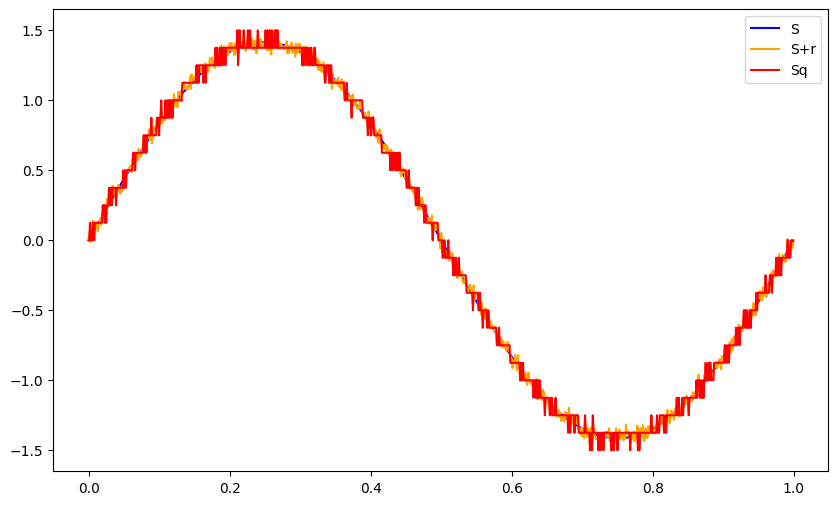

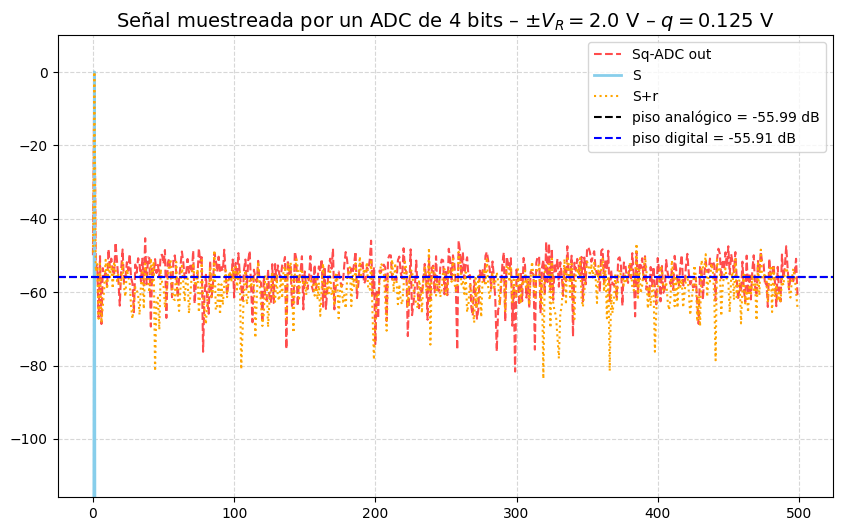

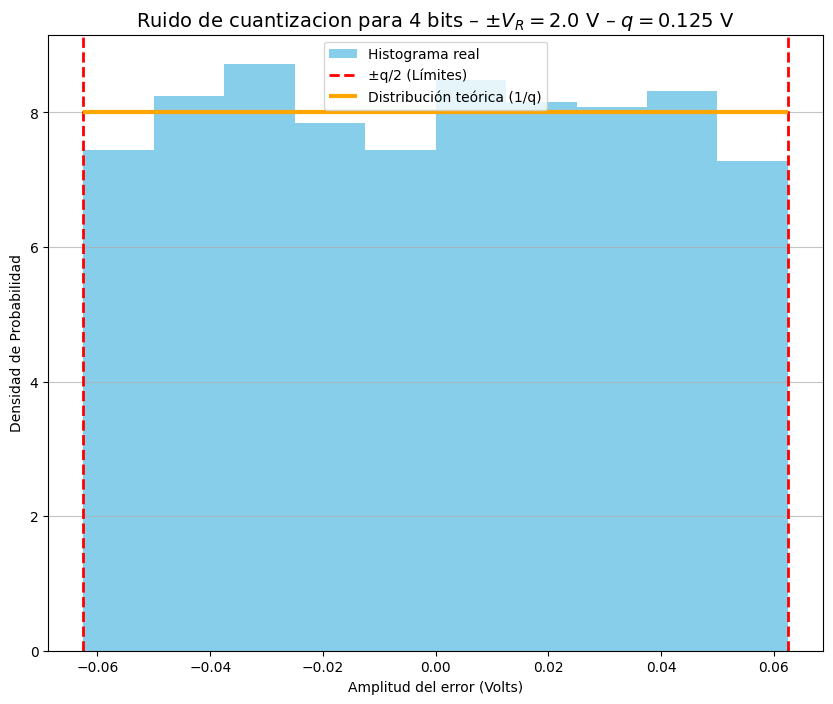

In [5]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 4 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=1
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)


### Analisis del primer procedimiento

En este primer experimento, se observa el comportamiento del ADC bajo condiciones de ruido equilibradas. Los puntos más relevantes del análisis son:

-En el gráfico temporal se observa la superposición de la señal original ($S$), la señal con ruido aditivo ($S+r$) y la salida del cuantizador ($Sq$).Efecto de Escalonamiento: Debido a la baja resolución de 4 bits, los niveles de cuantización son claramente visibles. La señal roja ($Sq$) "salta" entre los valores permitidos, evidenciando el paso $q = 0.125$ V.

-Coincidencia de los niveles de ruido: Tal como se observa en la leyenda, el piso analógico ($-55.69$ dB) y el piso digital ($-55.80$ dB) son casi idénticos. Esto valida experimentalmente la condición de diseño $P_n = 1 \cdot P_q$. La ligera diferencia decimal se atribuye al carácter estocástico del ruido generado en la simulación de N muestras finitas.

-Aumento de la varianza total: La señal de salida del ADC ($S_q$, línea roja discontinua) muestra una densidad de potencia que fluctúa alrededor de ambos pisos. Al ser errores incorrelados, las potencias se suman, lo que resulta en una señal de salida notablemente más degradada que la senoidal original ($S$).

-Distribución Uniforme: El error se distribuye de manera sensiblemente plana (uniforme) entre los límites teóricos de $\pm q/2$ (aproximadamente $\pm 0.0625$ V). Esto confirma la hipótesis de que el error de cuantización puede modelarse como ruido blanco cuando la señal es lo suficientemente compleja o tiene ruido aditivo.

-Densidad de Probabilidad: La altura del histograma real coincide con la línea naranja teórica ($1/q = 1/0.125 = 8$). Esto valida que la potencia del ruido de cuantización en la práctica responde a la fórmula $P_q = q^2/12$.

### Desarrollo parte B

#### B=4 Kn=1/10

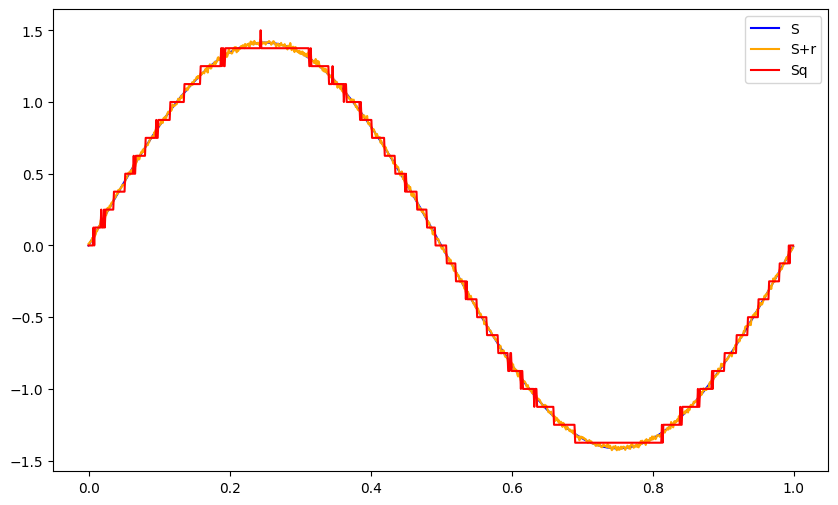

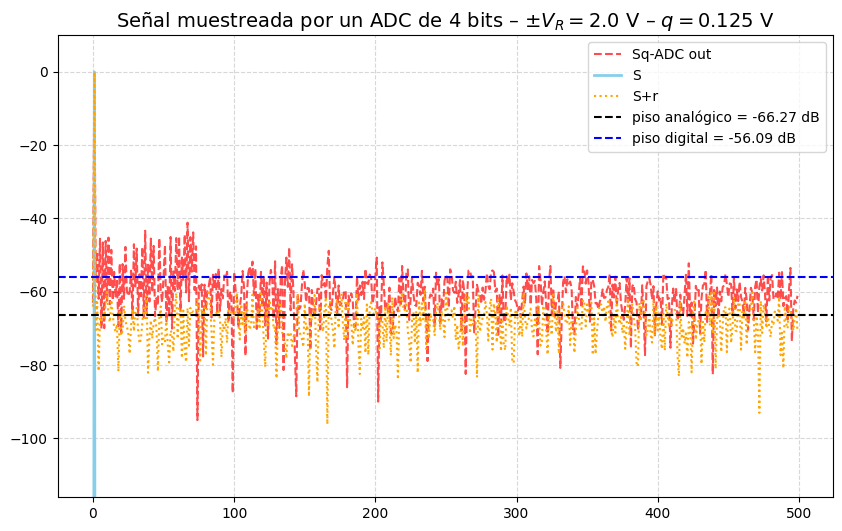

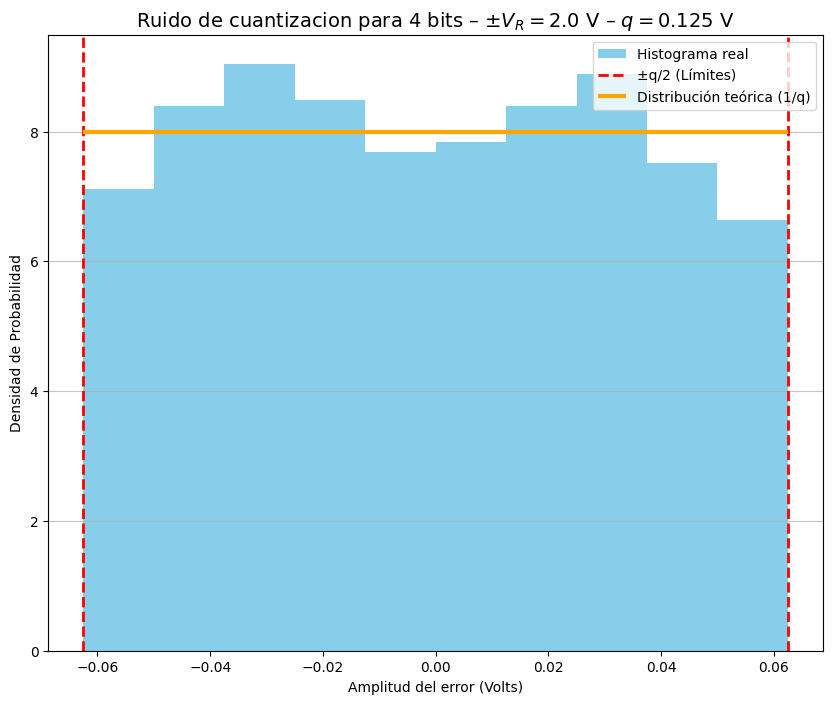

In [6]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 4 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=1/10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=4 Kn=10

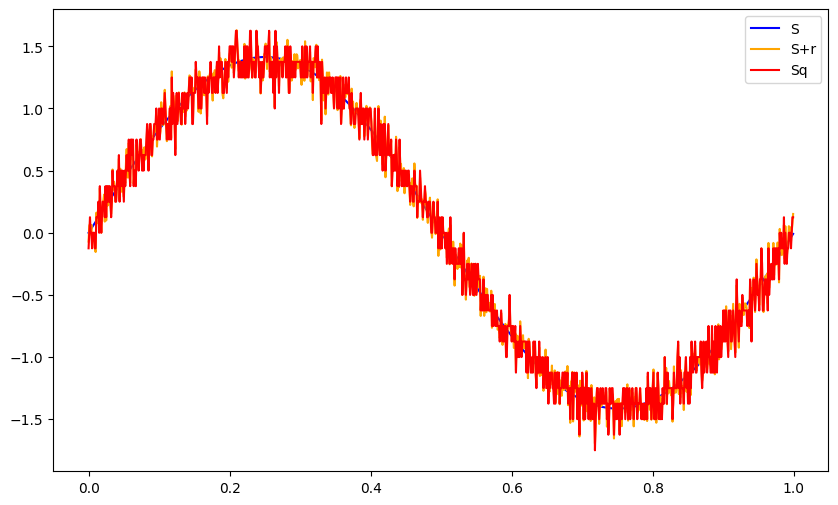

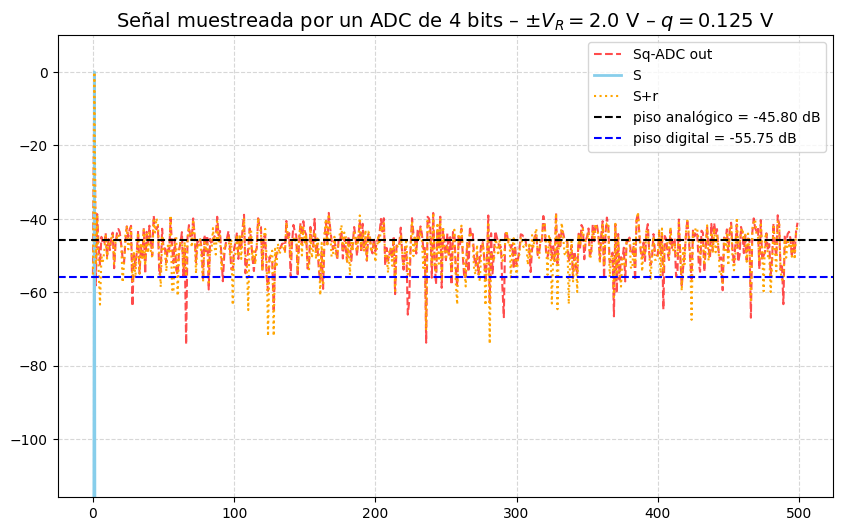

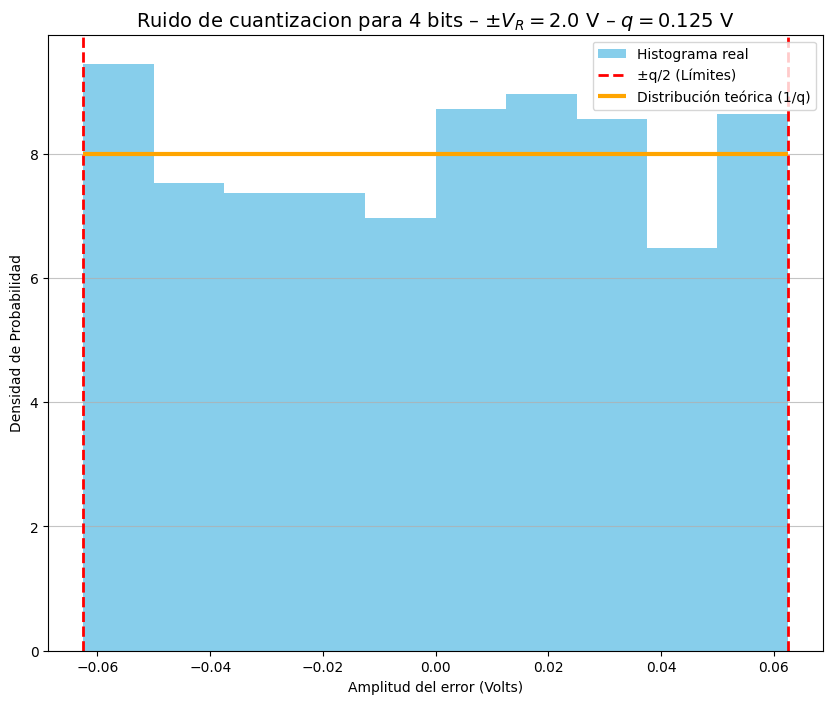

In [8]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 4 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=8 Kn=1/10

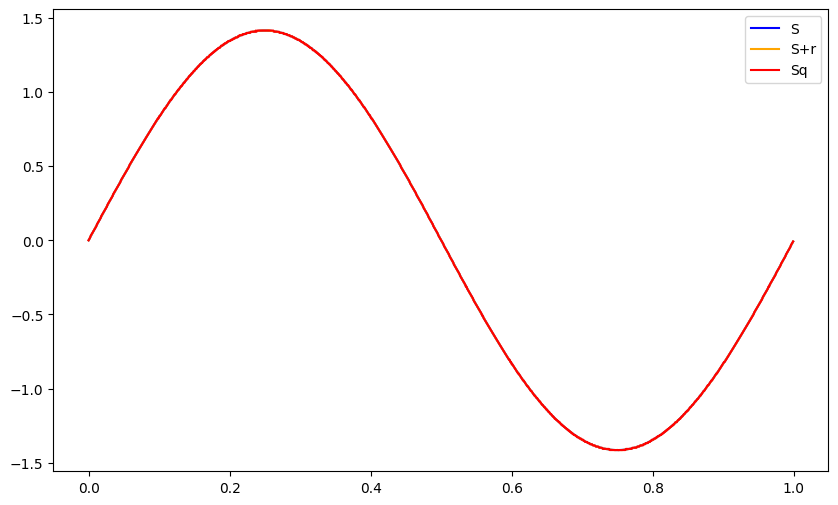

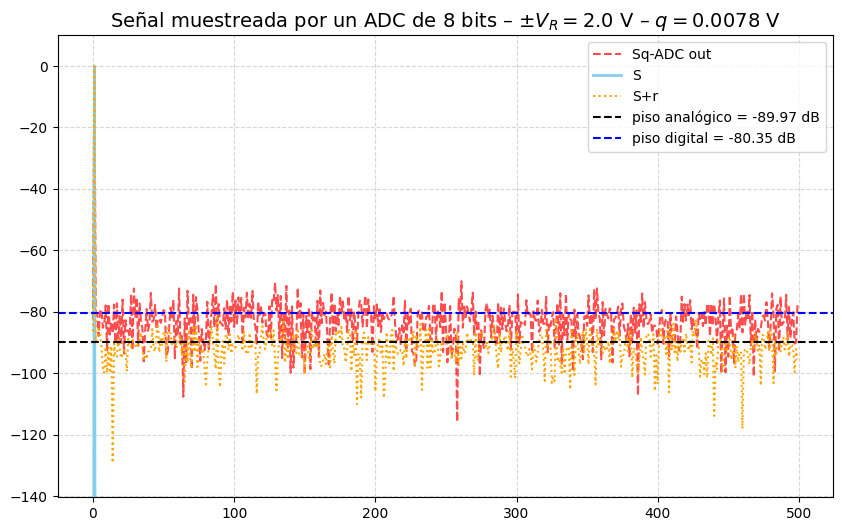

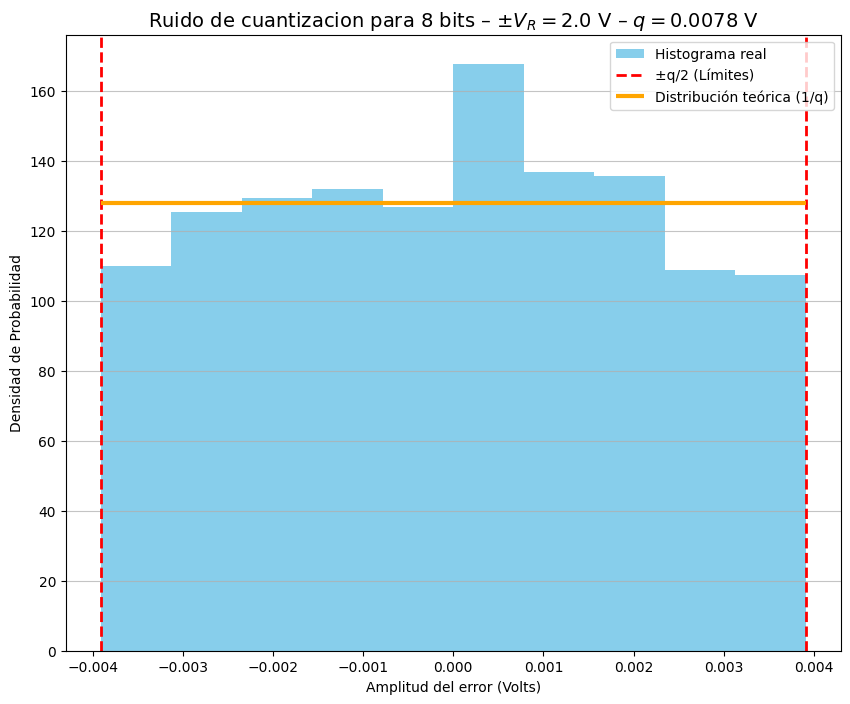

In [22]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 8 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=1/10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 8 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.4f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 8 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.4f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=8 Kn=1

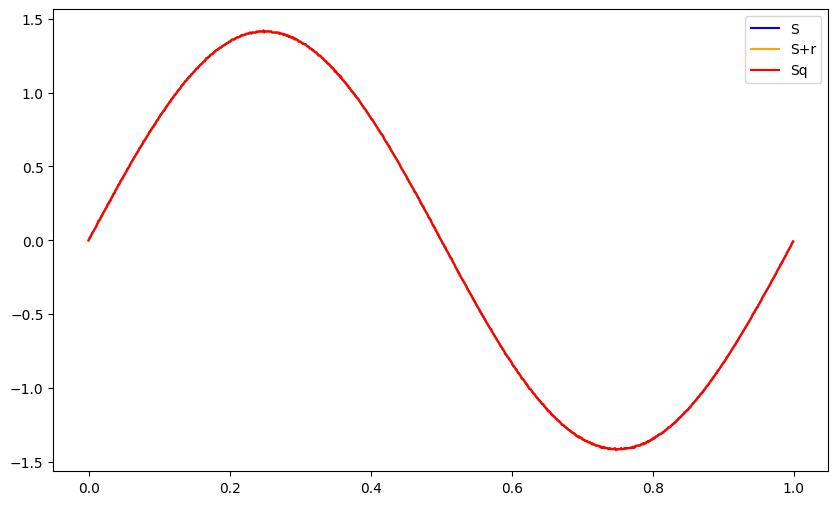

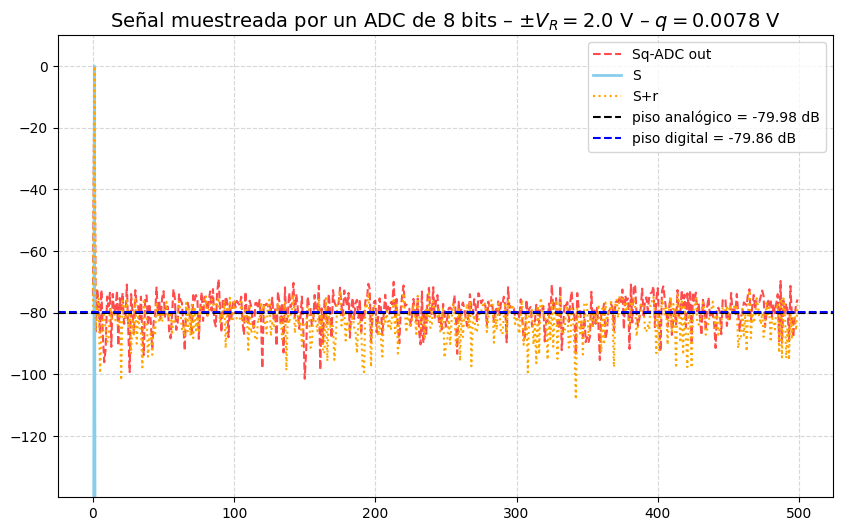

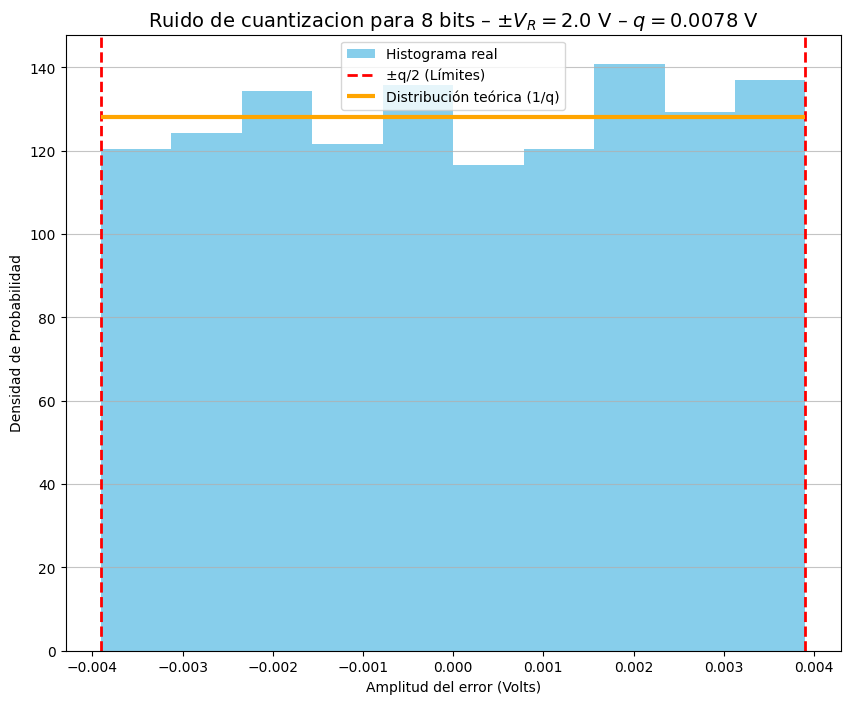

In [23]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 8 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=1
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 8 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.4f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 8 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.4f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=8 Kn=10

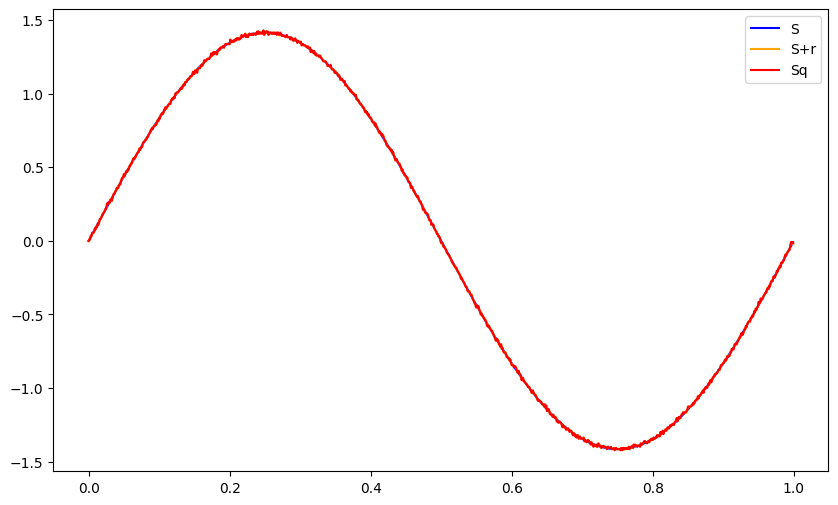

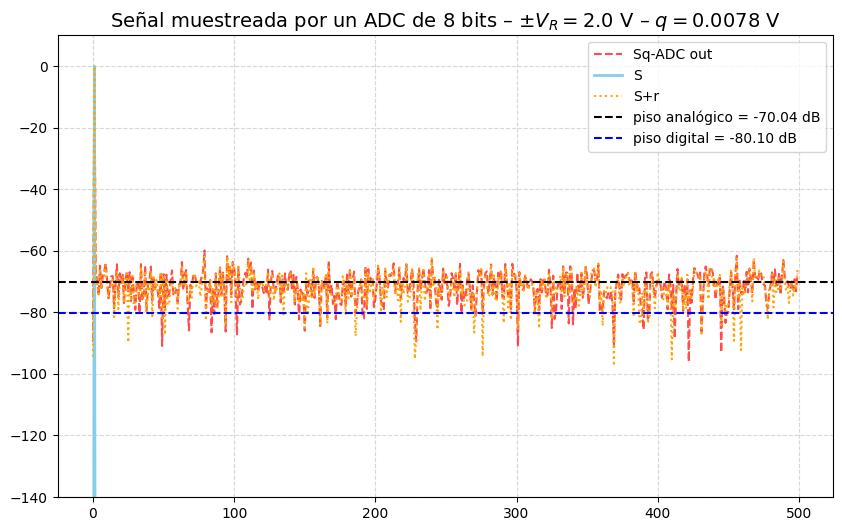

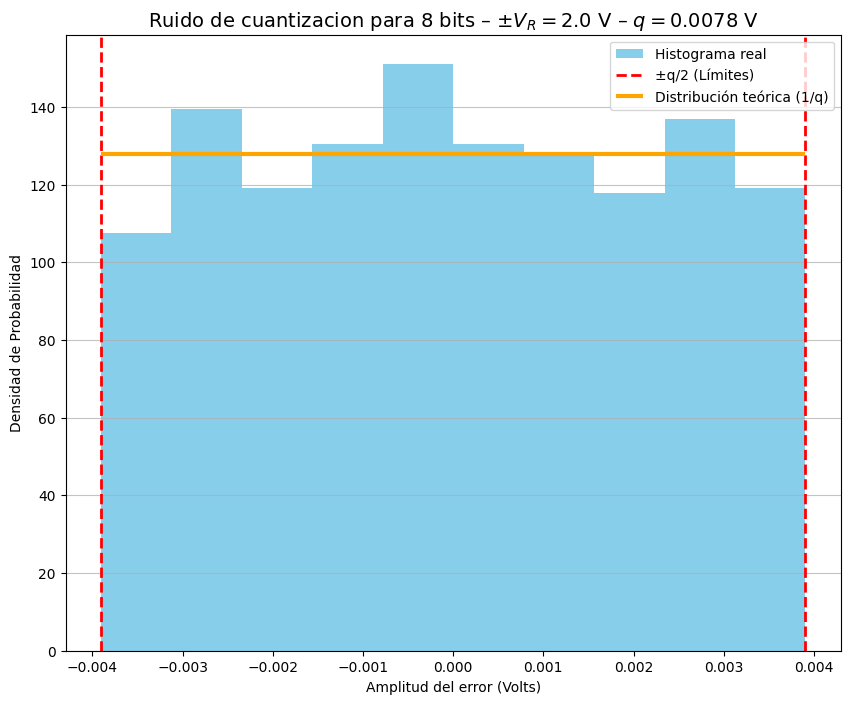

In [24]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 8 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 8 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.4f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 8 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.4f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=16 kn=1/10

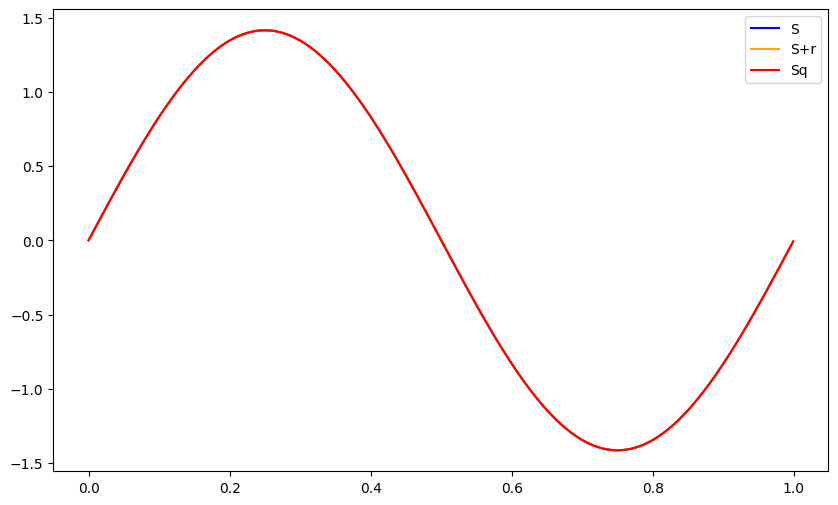

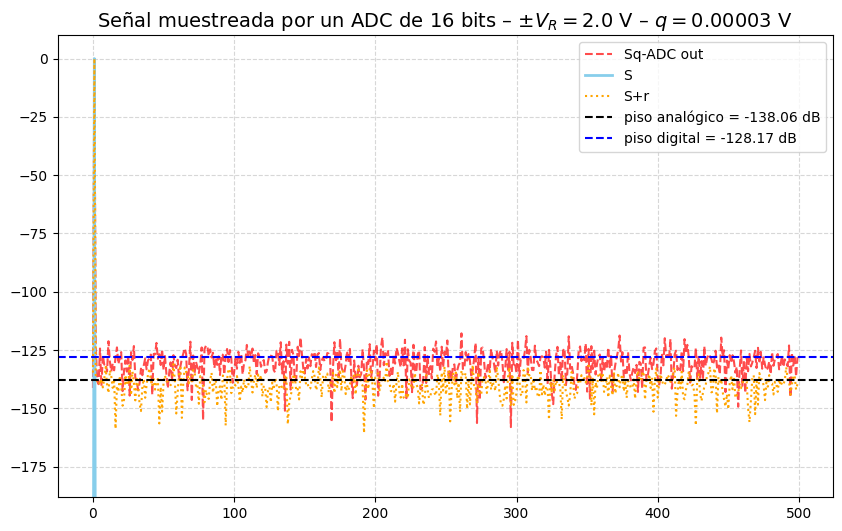

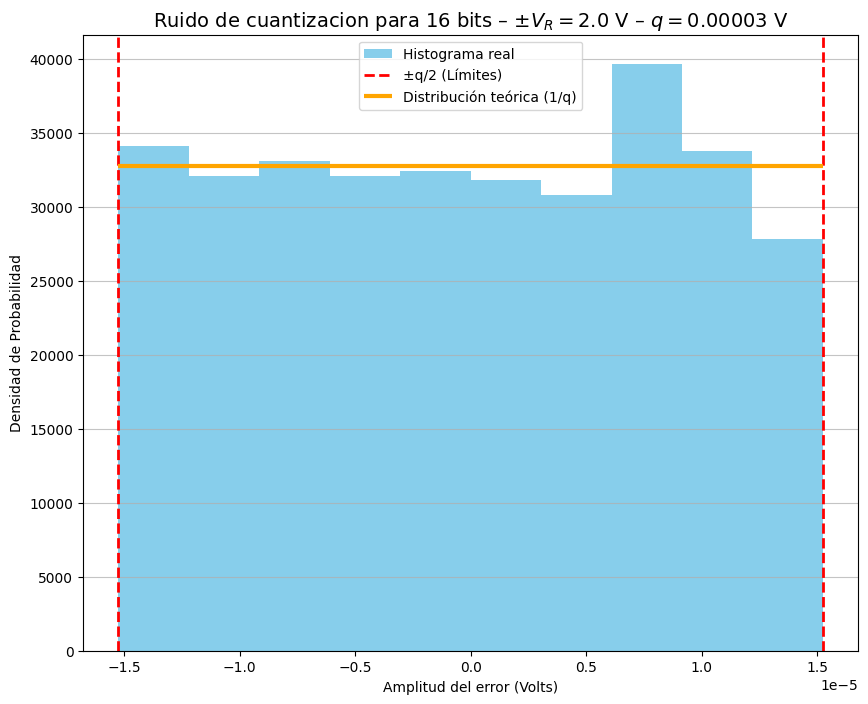

In [25]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 16 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=1/10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 16 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.5f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 16 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.5f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=16 Kn=1

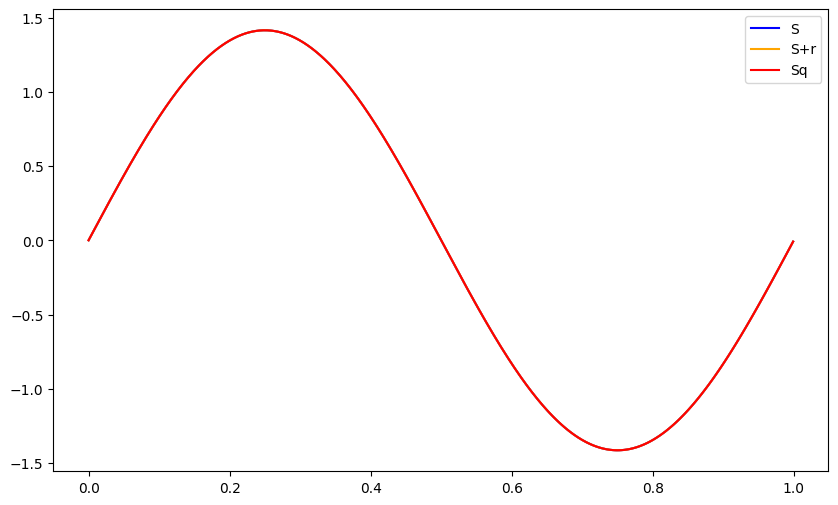

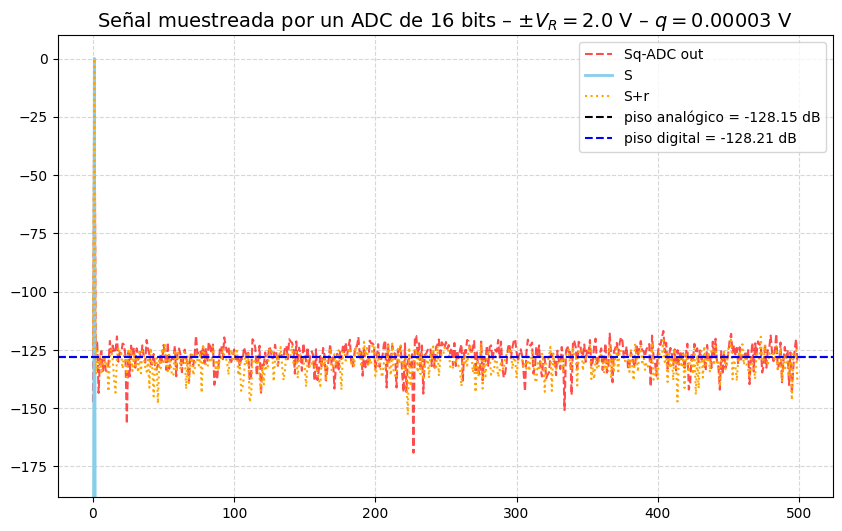

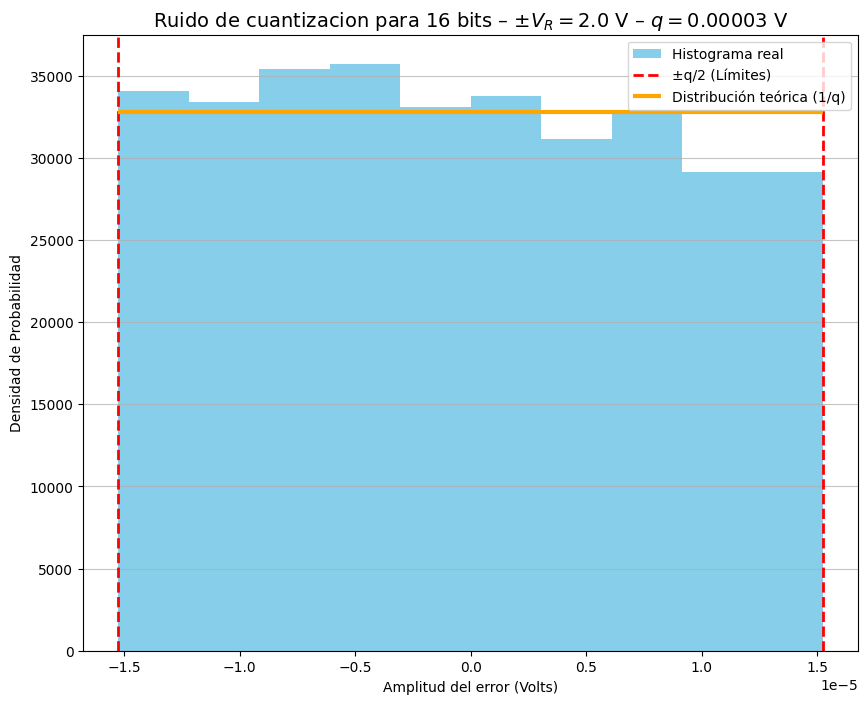

In [26]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 16 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=1
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 16 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.5f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 16 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.5f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

#### B=16 Kn=10

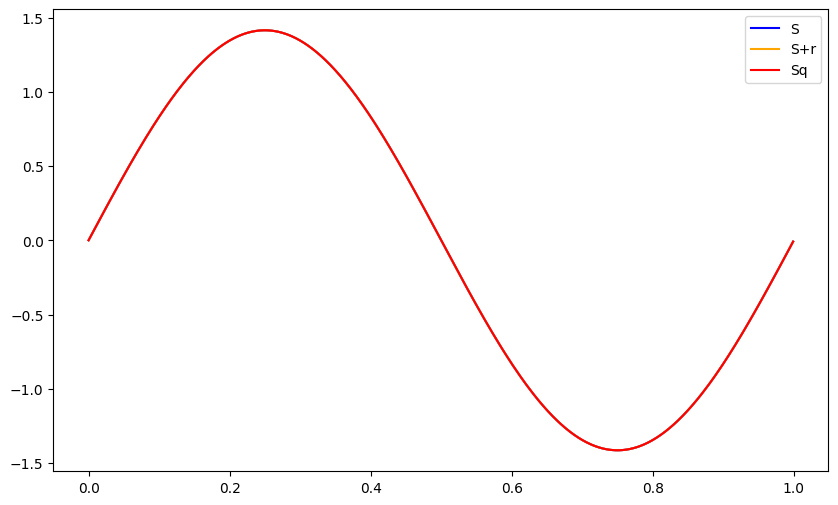

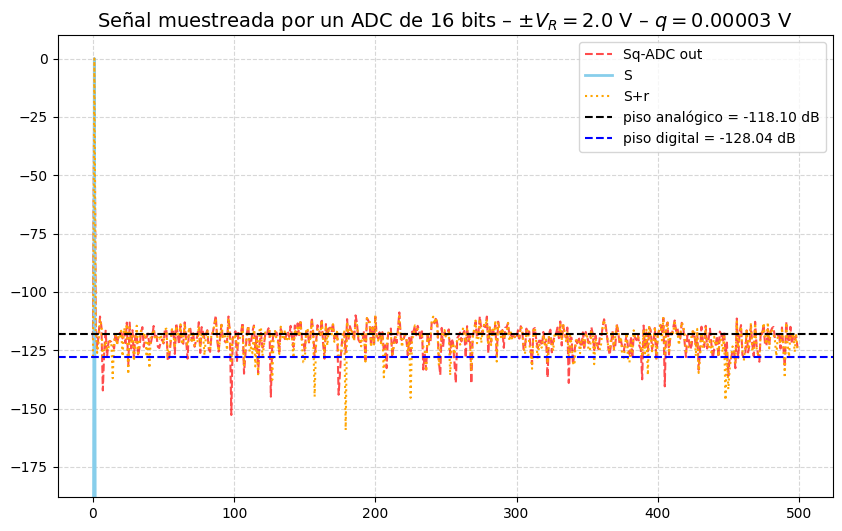

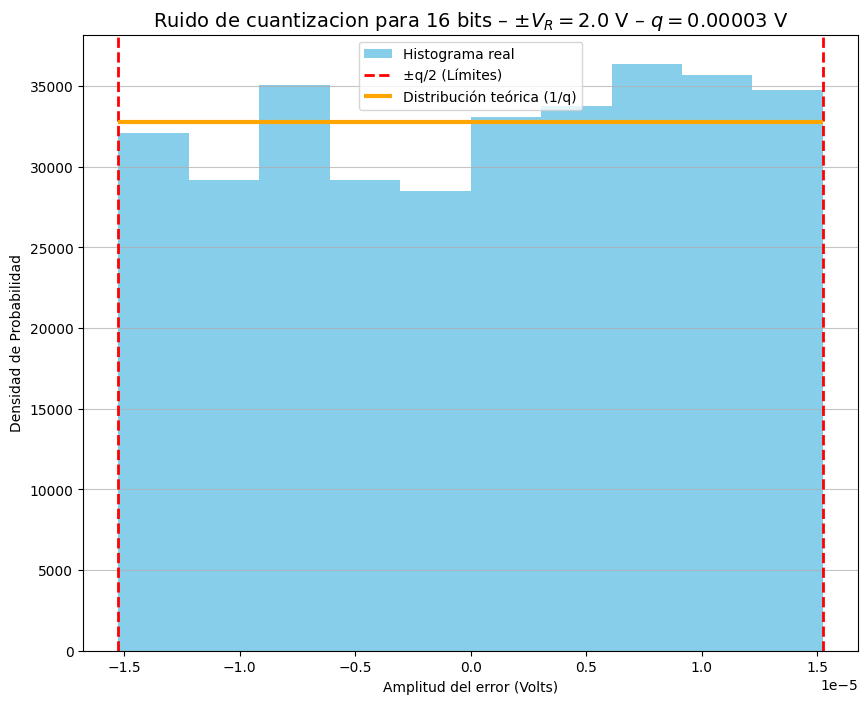

In [27]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funciones
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
    
def calcular_piso_ruido(espectro_potencia):
    # Buscamos el índice donde está el pico (la señal)
    idx_senal = np.argmax(espectro_potencia)
    
    # Creamos una copia para no romper el espectro original
    solo_ruido = espectro_potencia.copy()
    
    # "Borramos" el pico de la señal (y sus vecinos por si hay leakage)
    # Seteamos a NaN para que np.nanmean lo ignore
    solo_ruido[idx_senal] = np.nan
    if idx_senal > 0: solo_ruido[idx_senal-1] = np.nan
    if idx_senal < len(solo_ruido)-1: solo_ruido[idx_senal+1] = np.nan
    
    # Promediamos solo lo que quedó (el ruido puro)
    return np.nanmean(solo_ruido)

#%% ejecucion
vmax=np.sqrt(2)
dc=0
ff=1
ph=0
nn=1000
fs=1000

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,nn,fs)

#%% Parametros de ADC
B = 16 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

#%% fft
# Tomamos solo la mitad (frecuencias positivas)
half_nn = nn // 2

XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XX_half = XX[:half_nn]
# Multiplicamos por 2 para recuperar la amplitud de la sinusoide
# (porque la FFT reparte la energía en frecuencias + y -)
XXmod= np.abs(XX_half)*2
# Referencia de potencia máxima de la señal pura, Normalizacion por maximo
ref_potencia = np.max(XXmod**2)

XXmod_dB = 10 * np.log10(XXmod**2 / ref_potencia)

#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= np.abs(XXr[:half_nn]) * 2


XXrmod_dB = 10 * np.log10(XXrmod**2 / ref_potencia)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

plt.figure(1, figsize=(10, 6))
plt.clf()
plt.plot (tt,xx, label ='S', color='blue')
plt.plot(tt,xxn, label = 'S+r', color= 'orange')
plt.plot(tt,xxq, label= 'Sq', color='red')
plt.legend()

exxq= xxq-xxn

XXq = np.fft.fft(xxq)*1/nn

XXqmod = np.abs(XXq[:half_nn]) * 2

XXqmod_dB = 10 * np.log10(XXqmod**2 / ref_potencia)



#%% piso analogico y digital

# Calculamos la potencia total de la señal de error (ruido) en el tiempo
# Esto es universal: no importa la forma del ruido ni donde esté la señal.
potencia_ruido_analog_total = np.var(R) 
potencia_ruido_digital_total = np.var(exxq) # exxq es el error de cuantización

#  La potencia que ves en CADA BIN del espectro es la potencia total 
# dividida por la cantidad de bins (nn/2)
potencia_por_bin_analog = potencia_ruido_analog_total / (nn/2)
potencia_por_bin_digital = potencia_ruido_digital_total / (nn/2)

# 3. Referencia de potencia de la señal (P = A^2 / 2)
# Usamos la amplitud que recuperamos en la FFT (XXmod tiene el factor 2)
P_senal = (np.max(XXmod)**2) / 2

# 4. Calculamos los niveles en dB
piso_analog = 10 * np.log10(potencia_por_bin_analog / P_senal)
piso_digital = 10 * np.log10(potencia_por_bin_digital / P_senal)

plt.figure(2, figsize=(10, 6))
plt.clf()
plt.title(r"Señal muestreada por un ADC de 16 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.5f\ \text{V}$" % qq, fontsize=14)
plt.plot(XXqmod_dB, label='Sq-ADC out', color='red', linestyle='--', alpha=0.7)
plt.plot(XXmod_dB, label='S', color='skyblue', linewidth=2)
plt.plot(XXrmod_dB, label='S+r', color='orange', linestyle='dotted')

# Líneas de piso corregidas
plt.axhline(y=piso_analog, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog:.2f} dB')
plt.axhline(y=piso_digital, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital:.2f} dB')

plt.ylim([piso_digital - 60, 10]) # Ajusta el zoom vertical
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 16 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.5f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 10
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)

### Conclusiones

Fidelidad y Resolución: Como era de esperar, un incremento en el número de bits ($B$) reduce el paso de cuantización $q$, permitiendo que la señal digitalizada se aproxime con mayor precisión a la señal analógica original. El "escalonamiento" temporal se vuelve imperceptible a partir de los 8 bits en esta escala.

Predominancia de Ruido y el factor $k_n$: Se comprobó que la relación de potencias entre el ruido analógico y el de cuantización se traduce directamente en una diferencia logarítmica en el espectro (FFT):

$k_n = 1/10$ (-10 dB): El sistema está limitado por la cuantización (Quantization Limited). Aumentar los bits aquí mejora drásticamente la señal.

$k_n = 1$ (0 dB): Punto de equilibrio de diseño donde ambas fuentes de error contribuyen equitativamente.

$k_n = 10$ (+10 dB): El sistema está limitado por el ruido térmico/externo. En este caso, aumentar la resolución del ADC (más bits) es ineficiente, ya que el ruido analógico "tapa" la precisión ganada por el cuantizador.

Desplazamiento de los Pisos de Ruido: Es una observación clave notar que al aumentar $B$, ambos pisos descienden. Esto se debe a que el ruido analógico se definió en función de $P_q$. Al mejorar el ADC (menos $P_q$), la exigencia de ruido para mantener el factor $k_n$ es mayor, resultando en una señal globalmente más limpia en el espectro.

Límite Práctico: La simulación demuestra que la calidad de una digitalización no depende solo del ADC, sino de la relación entre el ruido que ya trae la señal y el ruido que introduce el dispositivo. Un ADC de 16 bits no ofrece ventajas reales si el ruido de entrada es superior al ruido de cuantización de un ADC de 8 bits.